# 2.4 Synthetic Look-Ahead Alpha Construction

In this section, we construct synthetic alpha signals from realized intraday price moves.

The purpose is not to build a realistic forecasting model. Instead, we create a controlled signal whose correlation with future returns can be chosen in advance. This allows us to test how the trading strategy behaves under different alpha strengths and decay.

The output of this section should eventually be an alpha panel with the same structure as the price panel:

$$
\text{index} = (\text{stock}, \text{date}),
\qquad
\text{columns} = \text{intraday time bins}.
$$

For each stock $i$, date $d$, and intraday time bin $t_j$, the alpha value $\alpha_{i,d,j}$ is a dimensionless return forecast.


## Baseline lecture construction

The construction used in the lecture notebook starts from the realized future price move over a short horizon.

Let

$$
P_{i,d,j}
$$

denote the observed mid-price of stock $i$ on date $d$ at intraday time bin $t_j$.

For a look-ahead horizon of $h$ bins, define the realized forward return

$$
r^{h}_{i,d,j}
=
\frac{P_{i,d,j+h} - P_{i,d,j}}{P_{i,d,j}}.
$$

This is dimensionless because it is a price change divided by a price. For example, if $r^{h}_{i,d,j}=0.001$, this corresponds to a 10 basis point future return.

The lecture notebook constructs a noisy synthetic return innovation of the form

$$
\tilde{\alpha}^{h}_{i,d,j}
=
\frac{
x\left(P_{i,d,j+h} - P_{i,d,j}\right)
+
y\left(W_{i,d,j+h} - W_{i,d,j}\right)
}
{P_{i,d,j}}.
$$

Equivalently,

$$
\tilde{\alpha}^{h}_{i,d,j}
=
x r^{h}_{i,d,j}
+
\frac{
y\left(W_{i,d,j+h} - W_{i,d,j}\right)
}
{P_{i,d,j}}.
$$

Here:

- $P_{i,d,j+h} - P_{i,d,j}$ is the realized future price move;
- $W_{i,d,j+h} - W_{i,d,j}$ is an independent noise shock;
- $x$ controls how much of the true future return enters the signal;
- $y$ controls the amount of noise added to the signal;
- $\tilde{\alpha}^{h}_{i,d,j}$ is a synthetic alpha innovation, measured in return units.

In the current implementation we use one-bin returns, so $h=1$. Since each bin is 10 seconds, this corresponds to a 10-second look-ahead return.

## Choosing $x$ and $y$

The parameters $x$ and $y$ are chosen so that the synthetic alpha innovation has a target correlation $\rho$ with the realized forward return.

For simplicity, write

$$
r = r^{h}_{i,d,j},
\qquad
\tilde{\alpha} = \tilde{\alpha}^{h}_{i,d,j},
\qquad
P = P_{i,d,j}.
$$

The synthetic innovation is

$$
\tilde{\alpha}
=
x r
+
\frac{y \Delta W}{P},
$$

where $\Delta W$ is independent of the return $r$.

Assuming $\Delta W$ has variance equal to $h$, we have

$$
\operatorname{Var}(\tilde{\alpha})
=
x^2 \operatorname{Var}(r)
+
y^2 \mathbb{E}\left[P^{-2}\right] h.
$$

The covariance between the synthetic innovation and the realized return is

$$
\operatorname{Cov}(\tilde{\alpha}, r)
=
x \operatorname{Var}(r).
$$

Therefore,

$$
\operatorname{Corr}(\tilde{\alpha}, r)
=
\frac{
x\sqrt{\operatorname{Var}(r)}
}
{
\sqrt{
x^2\operatorname{Var}(r)
+
y^2\mathbb{E}\left[P^{-2}\right]h
}
} = \rho
$$

The lecture construction also imposes the condition

$$
\mathbb{E}[r \mid \tilde{\alpha}] = \tilde{\alpha}.
$$

Under the usual jointly normal approximation, this gives the calibration

$$
x = \rho^2,
$$

and

$$
y
=
\rho\sqrt{1-\rho^2}
\sqrt{
\frac{
\operatorname{Var}(r)
}
{
\mathbb{E}\left[P^{-2}\right]h
}
}.
$$

In the code below, we work with one-bin noise increments, so effectively $h=1$. This is why the implemented formula uses

$$
y
=
\rho\sqrt{1-\rho^2}
\sqrt{
\frac{
\operatorname{Var}(r)
}
{
\mathbb{E}\left[P^{-2}\right]
}
}.
$$

## From alpha innovations to an alpha process

The lecture notebook then turns the synthetic innovations into an alpha process by cumulative summation:

$$
\alpha_{i,d,j}
=
\sum_{k \leq j}
\tilde{\alpha}_{i,d,k}.
$$

Equivalently,

$$
\alpha_{i,d,j}
=
\alpha_{i,d,j-1}
+
\tilde{\alpha}_{i,d,j}.
$$

This means that each new synthetic innovation permanently enters the alpha process.

The resulting alpha $\alpha_{i,d,j}$ is still measured in return units. A positive value means that the strategy receives a buy signal, while a negative value means that the strategy receives a sell signal.

The notebook compares this synthetic alpha process with the cumulative intraday return

$$
\frac{P_{i,d,j}}{P_{i,d,0}} - 1.
$$

This quantity is not a forward return. It is the realized cumulative return from the start of the trading day up to time $t_j$.

## Alpha level

The project also asks us to control the alpha level.

Once the raw decayed alpha process has been constructed, we can scale it by a constant $A_\alpha$:

$$
\alpha^{\text{scaled}}_{i,d,j}
=
A_\alpha \alpha_{i,d,j}.
$$

The parameter $A_\alpha$ controls the strength of the signal.

If $A_\alpha$ is small, the expected return signal is weak, so the optimal strategy should trade less aggressively.

If $A_\alpha$ is large, the expected return signal is stronger, so the strategy may trade more aggressively, accepting higher price impact in order to capture the alpha.

This will be useful later in the sensitivity analysis, where we compare strategy performance under weak and strong alpha signals.

### Data Loading

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import importlib
import os

import src.synthetic_alphas as synthetic_alphas

importlib.reload(synthetic_alphas)

from src.synthetic_alphas import *

In [3]:
train_px_df = pd.read_csv("data/train_px_201901_20.csv")
train_px_df = train_px_df.set_index(["stock", "date"]).ffill(axis="columns").bfill(axis="columns")

test_px_df = pd.read_csv("data/test_px_201902_20.csv")
test_px_df = test_px_df.set_index(["stock", "date"]).ffill(axis="columns").bfill(axis="columns")

In [4]:
train_px_df.head() # values = mid prices

09:30:00  09:30:10  09:30:20  09:30:30  09:30:40  09:30:50  \
stock date                                                                     
AAL   2019-01-02    31.525    31.520    31.535    31.515    31.485    31.435   
      2019-01-03    31.770    31.800    31.840    31.765    31.740    31.720   
      2019-01-04    30.420    30.480    30.480    30.500    30.610    30.610   
      2019-01-07    31.995    31.930    31.720    31.770    31.895    31.895   
      2019-01-08    33.375    33.475    33.630    33.540    33.540    33.540   

                  09:31:00  09:31:10  09:31:20  09:31:30  ...  15:58:30  \
stock date                                                ...             
AAL   2019-01-02    31.445    31.480    31.480    31.440  ...    32.455   
      2019-01-03    31.660    31.665    31.545    31.530  ...    30.085   
      2019-01-04    30.575    30.540    30.585    30.565  ...    32.085   
      2019-01-07    31.960    31.980    31.960    31.960  ...    33.025   
      2019-01-08    33.540    33.445    33.415    33.440  ...    32.405   

                  15:58:40  15:58:50  15:59:00  15:59:10  15:59:20  15:59:30  \
stock date                                                                     
AAL   2019-01-02    32.445    32.445    32.445    32.465    32.465    32.480   
      2019-01-03    30.100    30.115    30.120    30.125    30.115    30.095   
      2019-01-04    32.085    32.085    32.085    32.085    32.085    32.085   
      2019-01-07    33.045    33.045    33.035    33.025    32.990    32.975   
      2019-01-08    32.405    32.395    32.405    32.405    32.415    32.385   

                  15:59:40  15:59:50  16:00:00  
stock date                                      
AAL   2019-01-02    32.500    32.475    32.475  
      2019-01-03    30.075    30.015    30.015  
      2019-01-04    32.075    32.055    32.055  
      2019-01-07    32.975    32.955    32.955  
      2019-01-08    32.385    32.370    32.370  

[5 rows x 2341 columns]

### Estimating parameters

$$
\rho = \text{target\_corr}
$$

$$
h = \text{lookahead\_bins}
$$

$$
\operatorname{Var}\left(r_{i,d,j}^{h}\right)
=
\text{var\_forward\_return}
$$

$$
\mathbb{E}\left[P_{i,d,j}^{-2}\right]
=
\text{mean\_inv\_price\_sq}
$$

$$
x_i = \rho^2
$$

$$
y_i
=
\rho \sqrt{1-\rho^2}
\sqrt{
\frac{
\operatorname{Var}\left(r_{i,d,j}^{h}\right)
}{
\mathbb{E}\left[P_{i,d,j}^{-2}\right]h
}
}
$$

In [7]:
target_corr = 0.1

alpha_param_df = calibrate_synthetic_alpha_params(
    train_px_df=train_px_df,
    target_corr=target_corr,
    lookahead_bins=1
)

alpha_param_df.head()

,target_corr,lookahead_bins,var_forward_return,mean_inv_price_sq,x,y,n_obs
stock,,,,,,,
AAL,0.1,1,2.950766e-07,0.000912,0.01,0.001789,49140
AAPL,0.1,1,8.792250e-08,0.000042,0.01,0.004531,49140
ABBV,0.1,1,1.339609e-07,0.000137,0.01,0.003111,49140
ABT,0.1,1,8.676500e-08,0.000206,0.01,0.002041,49140
ADBE,0.1,1,1.153345e-07,0.000018,0.01,0.008011,49140


### Generating a synthetic alpha using the calibrated stock level

In [8]:
synthetic_alpha_df, synthetic_alpha_diagnostics_df = generate_synthetic_alpha_df(
    test_px_df=test_px_df,
    alpha_param_df=alpha_param_df,
    alpha_level=1.0,
    random_seed=1234
)

synthetic_alpha_df.head()

09:30:00  09:30:10  09:30:20  09:30:30  09:30:40  09:30:50  \
stock date                                                                     
AAL   2019-02-01 -0.000087 -0.000075 -0.000013  0.000014  0.000080  0.000237   
      2019-02-04  0.000098  0.000051  0.000051  0.000052  0.000103  0.000252   
      2019-02-05 -0.000023 -0.000070 -0.000060 -0.000121 -0.000184 -0.000155   
      2019-02-06 -0.000086 -0.000074 -0.000174 -0.000155 -0.000105 -0.000142   
      2019-02-07 -0.000029  0.000062  0.000120  0.000123  0.000157  0.000261   

                  09:31:00  09:31:10  09:31:20  09:31:30  ...  15:58:30  \
stock date                                                ...             
AAL   2019-02-01  0.000122  0.000176  0.000103  0.000117  ... -0.001214   
      2019-02-04  0.000217  0.000164  0.000153  0.000166  ... -0.000466   
      2019-02-05 -0.000232 -0.000244 -0.000275 -0.000337  ...  0.000340   
      2019-02-06 -0.000057 -0.000108 -0.000148 -0.000200  ... -0.001385   
      2019-02-07  0.000260  0.000300  0.000290  0.000337  ...  0.000868   

                  15:58:40  15:58:50  15:59:00  15:59:10  15:59:20  15:59:30  \
stock date                                                                     
AAL   2019-02-01 -0.001161 -0.001154 -0.001122 -0.001162 -0.001177 -0.001135   
      2019-02-04 -0.000488 -0.000455 -0.000442 -0.000430 -0.000343 -0.000371   
      2019-02-05  0.000420  0.000440  0.000399  0.000430  0.000348  0.000401   
      2019-02-06 -0.001307 -0.001267 -0.001255 -0.001216 -0.001287 -0.001390   
      2019-02-07  0.000921  0.000900  0.000914  0.000853  0.000844  0.000768   

                  15:59:40  15:59:50  16:00:00  
stock date                                      
AAL   2019-02-01 -0.001175 -0.001188 -0.001188  
      2019-02-04 -0.000403 -0.000424 -0.000424  
      2019-02-05  0.000440  0.000401  0.000401  
      2019-02-06 -0.001341 -0.001309 -0.001309  
      2019-02-07  0.000791  0.000712  0.000712  

[5 rows x 2341 columns]

In [9]:
synthetic_alpha_diagnostics_df.head()

,target_corr,realized_return_corr,realized_alpha_corr,alpha_level,lookahead_bins,x,y,n_obs
stock,,,,,,,,
AAL,0.1,0.069670,-0.001124,1.0,1,0.01,0.001789,44460
AAPL,0.1,0.077378,0.005577,1.0,1,0.01,0.004531,44460
ABBV,0.1,0.060371,0.000352,1.0,1,0.01,0.003111,44460
ABT,0.1,0.068569,-0.001736,1.0,1,0.01,0.002041,44460
ADBE,0.1,0.070204,0.005094,1.0,1,0.01,0.008011,44460


### Plotting synthetic alpha paths

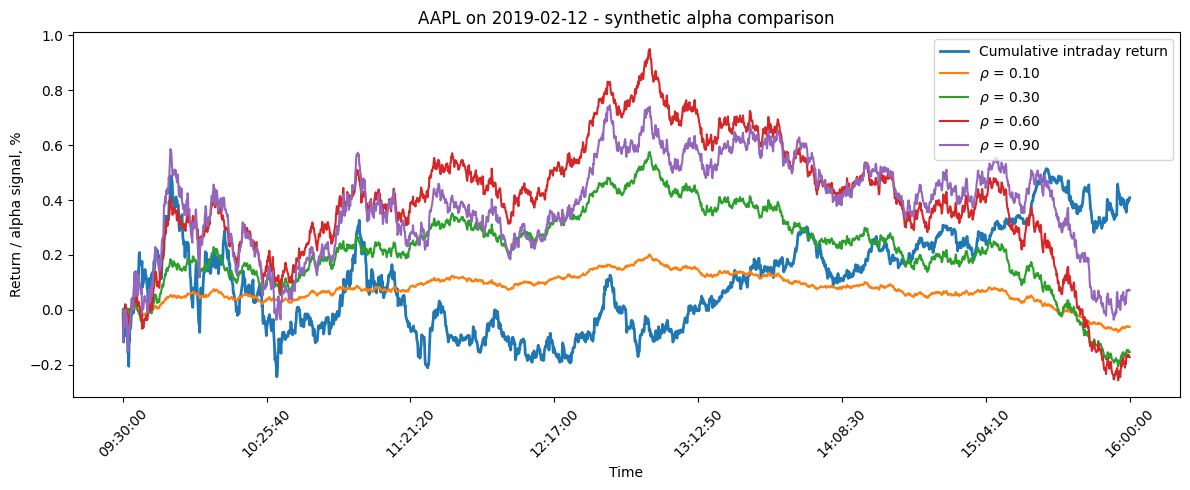

In [11]:
# Compare target correlation
plot_synthetic_alpha_parameter_comparison(
    train_px_df=train_px_df,
    test_px_df=test_px_df,
    stock="AAPL",
    date="2019-02-12",
    comparison_type="target_corr",
    values=[0.1, 0.3, 0.6, 0.9],
    alpha_level=1.0,
    lookahead_bins=1,
    random_seed=1234
)

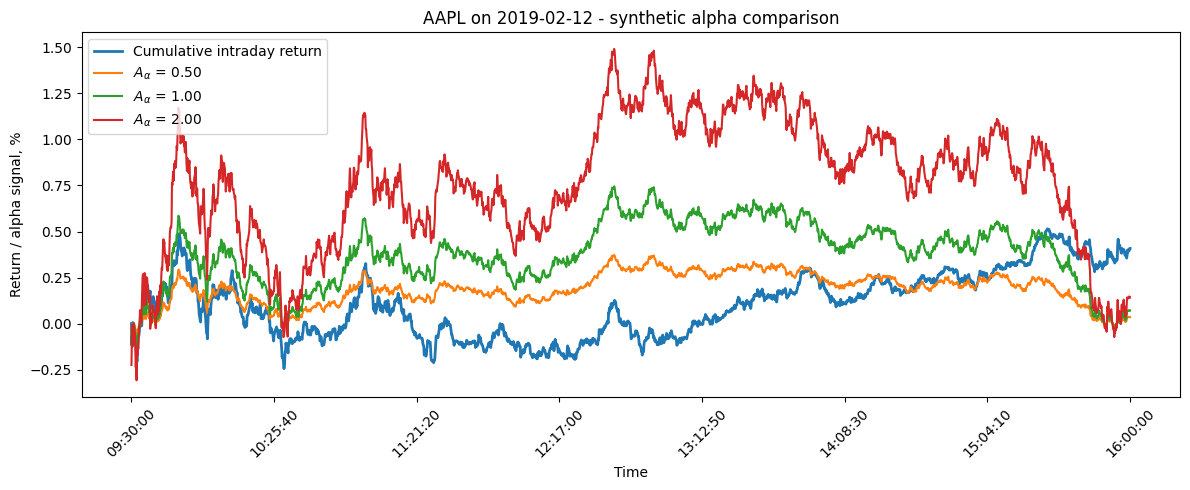

In [12]:
# Compare alpha level

plot_synthetic_alpha_parameter_comparison(
    train_px_df=train_px_df,
    test_px_df=test_px_df,
    stock="AAPL",
    date="2019-02-12",
    comparison_type="alpha_level",
    values=[0.5, 1.0, 2.0],
    target_corr=0.9,
    lookahead_bins=1,
    random_seed=1234
)

In [ ]:
synthetic_alpha_decay_df = generate_synthetic_alpha_decay_df(
    synthetic_alpha_df=synthetic_alpha_df,
    dt_seconds=10
)

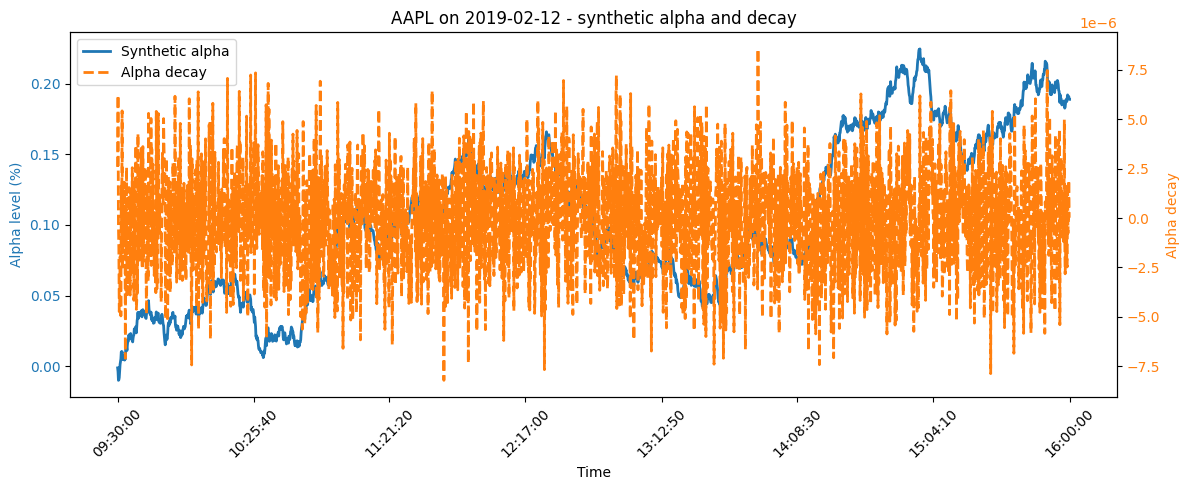

In [22]:
plot_synthetic_alpha_decay(
    synthetic_alpha_df=synthetic_alpha_df,
    synthetic_alpha_decay_df=synthetic_alpha_decay_df,
    stock="AAPL",
    date="2019-02-12",
)

### Saving Data

In [23]:
result_path = "data/"

alpha_param_df.to_csv(
    os.path.join(result_path, "synthetic_alpha_params_201901_train_20.csv"),
    index=True
)

synthetic_alpha_df.to_csv(
    os.path.join(result_path, "synthetic_alpha_201902_20.csv"),
    index=True
)

synthetic_alpha_diagnostics_df.to_csv(
    os.path.join(result_path, "synthetic_alpha_diagnostics_201902_20.csv"),
    index=True
)